In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report,confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [32]:
np.random.seed(42)
rows = 10000
humidity = np.random.randint(30, 100, rows)
moist = np.random.randint(100, 200, rows)
weather = ((0.75 * humidity + 0.25 * moist) > 95).astype(int)
data = {"Humidity": humidity, "Moist": moist, "Weather": weather}
df = pd.DataFrame(data)
df.head()

,Humidity,Moist,Weather
0,81,164,1
1,44,137,0
2,90,176,1
3,50,110,0
4,53,109,0


In [33]:
x=df.drop(columns=["Weather"])
y=df["Weather"]

In [38]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)
x = pd.DataFrame(x_scaled, columns=x.columns)
x.head()

,Humidity,Moist
0,0.815234,0.513466
1,-1.017542,-0.426253
2,1.261044,0.931119
3,-0.720335,-1.365973
4,-0.571732,-1.400777


In [35]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)


----------Using linear kernel----------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1366
           1       0.99      0.99      0.99       634

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000

Weight : [12.43948032  5.6828187 ]
Intercept : -7.692135626617049


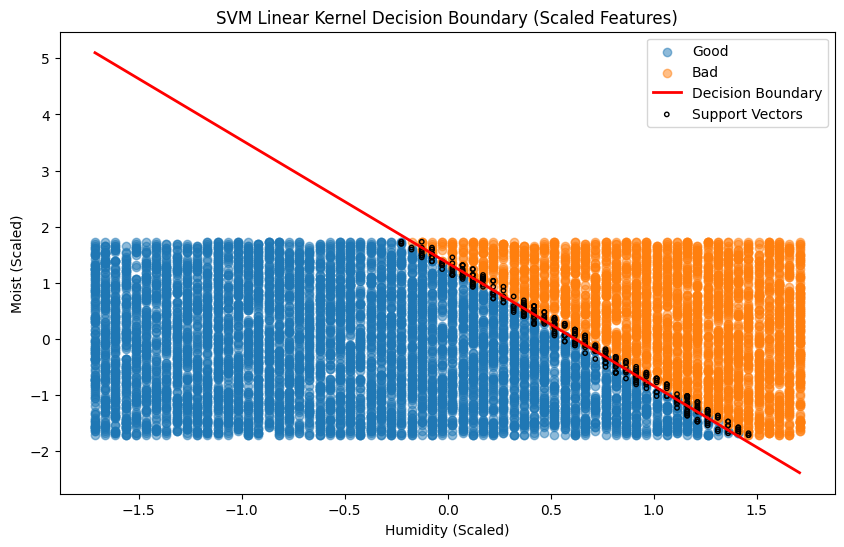


----------Using poly kernel----------
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1366
           1       1.00      0.97      0.98       634

    accuracy                           0.99      2000
   macro avg       0.99      0.98      0.99      2000
weighted avg       0.99      0.99      0.99      2000


----------Using rbf kernel----------
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1366
           1       0.99      0.99      0.99       634

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000


----------Using sigmoid kernel----------
              precision    recall  f1-score   support

           0       0.89      0.91      0.90      1366
           1       0.79      0.77      0.78       634

    accuracy                           0.86      2000
   macro 

In [36]:
for i in ["linear","poly","rbf","sigmoid"]:
  print(f"\n----------Using {i} kernel----------")
  model=SVC(kernel=i,random_state=42)
  model.fit(x_train,y_train)
  y_pred=model.predict(x_test)
  print(classification_report(y_test,y_pred))
  if i == "linear":
    w = model.coef_[0]
    b = model.intercept_[0]
    print(f"Weight : {w}\nIntercept : {b}")
    plt.figure(figsize=(10, 6))
    plt.scatter(x[y==0]["Humidity"], x[y==0]["Moist"], label="Good", alpha=0.5)
    plt.scatter(x[y==1]["Humidity"], x[y==1]["Moist"], label="Bad", alpha=0.5)
    x_min, x_max = x["Humidity"].min(), x["Humidity"].max()
    x_values = np.linspace(x_min, x_max, 100)
    y_values = -(w[0] * x_values + b) / w[1]
    plt.plot(x_values, y_values, color='red', linewidth=2, label="Decision Boundary")
    sv = model.support_vectors_
    plt.scatter(sv[:, 0], sv[:, 1], facecolors='none', edgecolors='black', s=10, label="Support Vectors")
    plt.xlabel("Humidity (Scaled)")
    plt.ylabel("Moist (Scaled)")
    plt.title("SVM Linear Kernel Decision Boundary (Scaled Features)")
    plt.legend()
    plt.show()

In [37]:
print(confusion_matrix(y_test,y_pred))

[[1240  126]
 [ 146  488]]
